In [479]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
import shap
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.feature_selection import RFECV
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

In [480]:
df = pd.read_csv('../../../data/preprocessed/selected_features_dataset_v2.csv')

X = df.drop(['price_per_m2'], axis=1)
y = df['price_per_m2']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [481]:
rf_model = RandomForestRegressor(random_state=42, n_jobs=-1)

In [482]:
rf = RandomForestRegressor(
    random_state=42, 
    n_jobs=-1,
    max_depth=4,
    n_estimators=100
)

rf.fit(X_train, y_train)


RandomForestRegressor(max_depth=4, n_jobs=-1, random_state=42)

In [483]:
# tuned_rf = rf.best_estimator_
# best_params = rf.best_params_
# print(f"Best R² from RandomizedSearchCV: {rf.best_score_:.4f}")
# print(f"Best parameters: {best_params}")

In [484]:
y_pred_test = rf.predict(X_test)
y_pred_train = rf.predict(X_train)


In [485]:
r2 = r2_score(y_test, y_pred_test)
mae = mean_absolute_error(y_test, y_pred_test)
mape = np.mean(np.abs((y_test - y_pred_test) / np.maximum(y_test, 1e-8))) * 100 
r2_train = r2_score(y_train, y_pred_train)
mae_train = mean_absolute_error(y_train, y_pred_train)
mape_train = np.mean(np.abs((y_train - y_pred_train) / np.maximum(y_train, 1e-8))) * 100 

In [486]:
# Print results
print(f"Test R² Score: {r2:.4f}")
print(f"Test MAE: {mae:.2f}")
print(f"Test MAPE: {mape:.2f}%\n")

print(f"Train R² Score: {r2_train:.4f}")
print(f"Train MAE: {mae_train:.2f}")
print(f"Train MAPE: {mape_train:.2f}%")

Test R² Score: 0.8534
Test MAE: 448.60
Test MAPE: 72.15%

Train R² Score: 0.8616
Train MAE: 442.24
Train MAPE: 72.09%


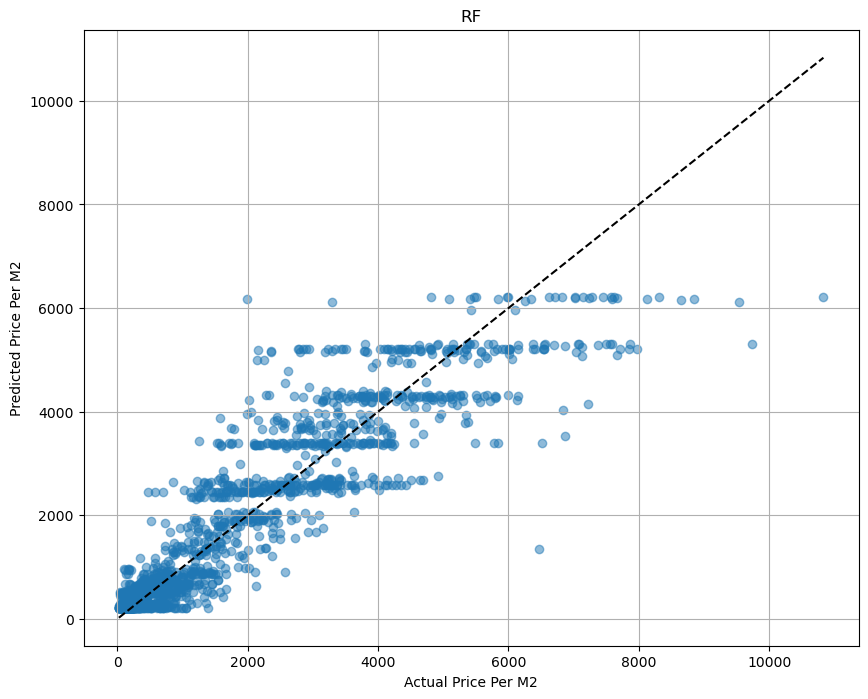

In [487]:
def plot_actual_vs_predicted(y_true, y_pred):
    plt.figure(figsize=(10, 8))
    plt.scatter(y_true, y_pred, alpha=0.5)
    plt.plot([y_true.min(), y_true.max()], 
             [y_true.min(), y_true.max()], 'k--')
    plt.xlabel('Actual Price Per M2')
    plt.ylabel('Predicted Price Per M2')
    plt.title('RF')
    plt.grid(True)
    plt.savefig("rf_actual_vs_predicted.png")
    plt.show()

plot_actual_vs_predicted(y_test, y_pred_test)

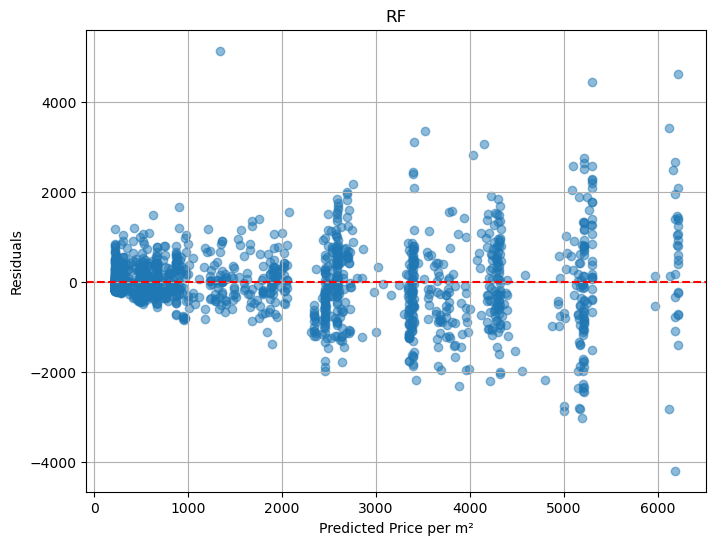

In [488]:
residuals = y_test - y_pred_test
plt.figure(figsize=(8, 6))
plt.scatter(y_pred_test, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Price per m²")
plt.ylabel("Residuals")
plt.title("RF")
plt.grid(True)
plt.show()

In [489]:
# joblib.dump(tuned_rf, "../../../models/random_forest/random_forest_model_v5_label.joblib")